<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
x = data.data
y = data.target

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=45, stratify=y)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo = DecisionTreeClassifier(random_state=45)
modelo.fit(x_treino, y_treino)

predicao_treino = modelo.predict(x_treino)
predica_teste = modelo.predict(x_teste)

acuracia_treino = accuracy_score(y_treino, predicao_treino)
print(acuracia_treino)
acuracia_teste = accuracy_score(y_teste, predica_teste)
print(acuracia_teste)

1.0
0.8666666666666667


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

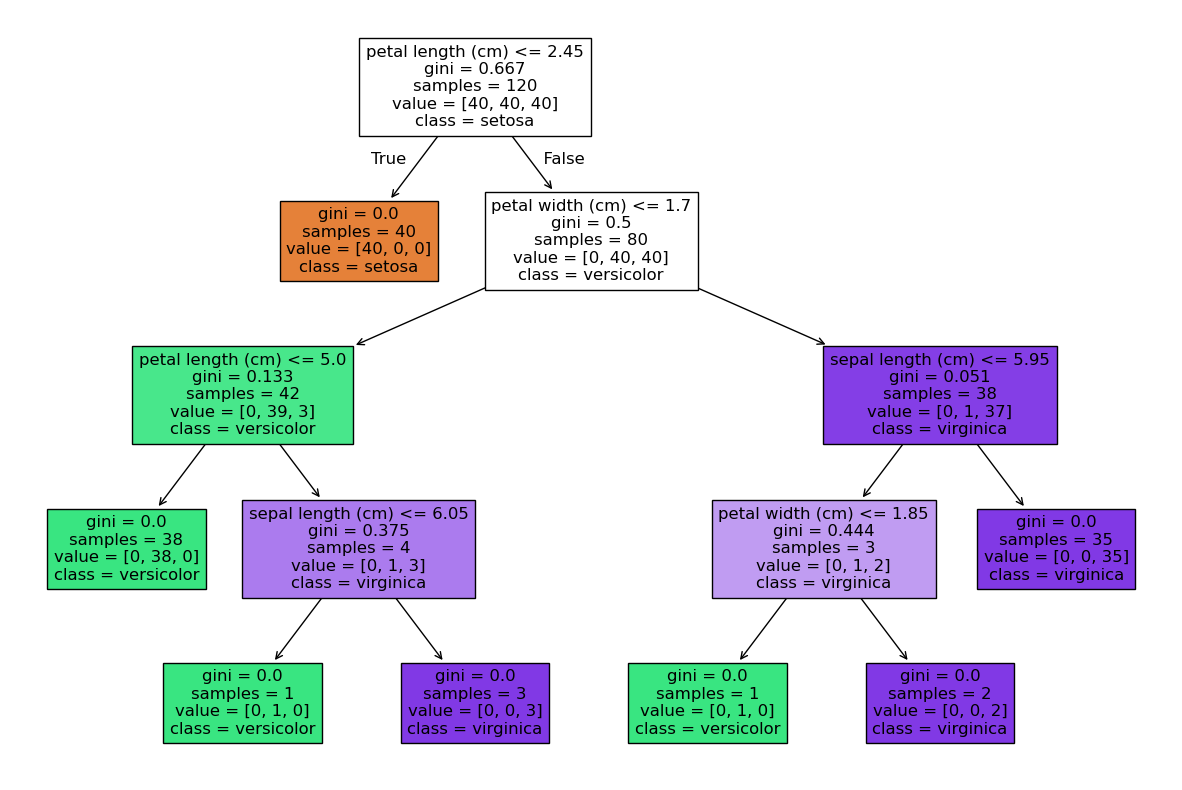

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

iris = load_iris()

plt.figure(figsize=(15,10))
plot_tree(modelo, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

## Petal lenght(cm)
## 4

Questão 1: Petal lenght(cm)
Questão 2: 4

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidade = [1,2,3,4,5,6,7,8,9,None]
tabela = []

for i in profundidade:
    modelo = DecisionTreeClassifier(max_depth=i, random_state=45)
    modelo.fit(x_treino, y_treino)

    predicao_treino = modelo.predict(x_treino)
    predica_teste = modelo.predict(x_teste)

    acuracia_treino = accuracy_score(y_treino, predicao_treino)
    acuracia_teste = accuracy_score(y_teste, predica_teste)

    iris = {"acuracia_treino": acuracia_treino,"acuracia_teste": acuracia_teste, "profundidade árvore": modelo.get_depth(), "número de folhas": modelo.get_n_leaves()}
    tabela.append(iris)

tabela_final = pd.DataFrame(tabela)
print(tabela_final)


   acuracia_treino  acuracia_teste  profundidade árvore  número de folhas
0         0.666667        0.666667                    1                 2
1         0.966667        0.933333                    2                 3
2         0.983333        0.933333                    3                 5
3         1.000000        0.866667                    4                 7
4         1.000000        0.866667                    4                 7
5         1.000000        0.866667                    4                 7
6         1.000000        0.866667                    4                 7
7         1.000000        0.866667                    4                 7
8         1.000000        0.866667                    4                 7
9         1.000000        0.866667                    4                 7


Questão 1: Pode se dizer então que o overfitting começa no depth igual a 4 (linha 3) pois ele começa a cravar 100% no teste, mas na prática não sai de 86%. 
Questão 2: Porque ele cria uma regrada para cada íris do dataset.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

criterio = ['gini', 'entropy']
comparacao = []

for c in criterio:
    modeloC = DecisionTreeClassifier(criterion=c, random_state=45)
    modeloC.fit(x_treino, y_treino)

    profundidade = modeloC.get_depth()
    acuracia_teste = accuracy_score(y_teste, modeloC.predict(x_teste))

    compara = {'criterio': c, 'profundidade': profundidade, 'acuracia_teste': acuracia_teste}
    comparacao.append(compara)

df_comparacao = pd.DataFrame(comparacao)
print(df_comparacao)

  criterio  profundidade  acuracia_teste
0     gini             4        0.866667
1  entropy             4        0.866667


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [20]:
folhas = [1, 2, 5, 10, 20]
investigacao = []

for m in folhas:
    modelo_leaf = DecisionTreeClassifier(min_samples_leaf=m, random_state=45)
    modelo_leaf.fit(x_treino, y_treino)
    
    acc_treino = accuracy_score(y_treino, modelo_leaf.predict(x_treino))
    acc_teste = accuracy_score(y_teste, modelo_leaf.predict(x_teste))
    
    investigacao.append({
        "min_samples_leaf": m,
        "acuracia_treino": acc_treino,
        "acuracia_teste": acc_teste
    })

df_investigacao = pd.DataFrame(investigacao)
print(df_investigacao)

   min_samples_leaf  acuracia_treino  acuracia_teste
0                 1         1.000000        0.866667
1                 2         0.983333        0.933333
2                 5         0.966667        0.933333
3                10         0.966667        0.933333
4                20         0.966667        0.933333
